Name: Kanna Venkata Sai Darsith  
Enrollment No: 23115061  
Sub Batch: EE3  
Topic : Loan Approval Status




In [9]:
import pandas as pd

data = pd.read_csv(r"/content/loan_data.csv")
data.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [11]:
data.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


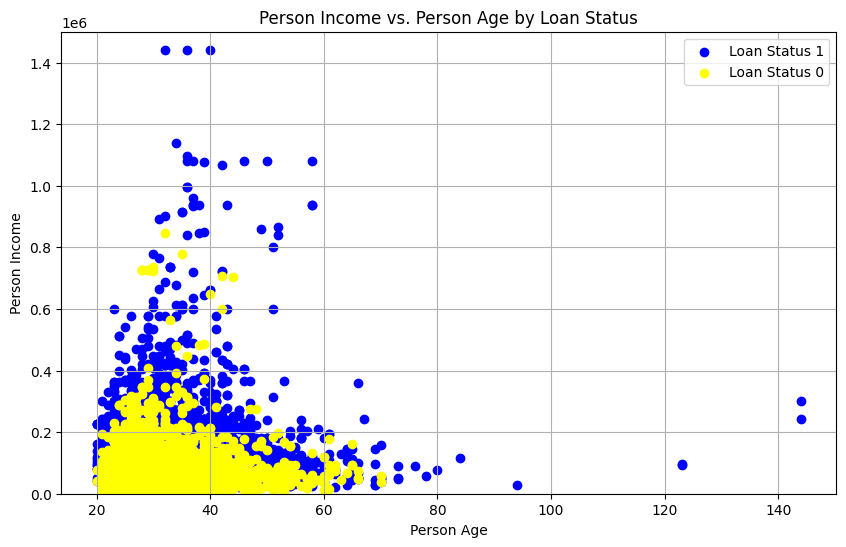

In [52]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

plt.scatter(data[data['loan_status'] == 0]['person_age'], data[data['loan_status'] == 0]['person_income'], color='blue', label='Loan Status 1')

plt.scatter(data[data['loan_status'] == 1]['person_age'], data[data['loan_status'] == 1]['person_income'], color='yellow', label='Loan Status 0')
plt.ylim(0, 1500000)
plt.xlabel('Person Age')
plt.ylabel('Person Income')
plt.title('Person Income vs. Person Age by Loan Status')
plt.legend()
plt.grid(True)
plt.show()


**Split into training and testing sets and standardise using StandardScalar**

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder


X = data.drop('loan_status', axis=1)
y = data['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

categorical_features = X_train.select_dtypes(include=['object']).columns

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_data_train = encoder.fit_transform(X_train[categorical_features])
encoded_data_test = encoder.transform(X_test[categorical_features])

encoded_df_train = pd.DataFrame(encoded_data_train, columns=encoder.get_feature_names_out(categorical_features), index=X_train.index)
encoded_df_test = pd.DataFrame(encoded_data_test, columns=encoder.get_feature_names_out(categorical_features), index=X_test.index)

**Train and evaluate the following
models on the standardized dataset:  
• Logistic Regression  
• Decision Tree  
• Random Forest  
• Support Vector Machine (SVM)**


Logistic Regression:
              precision    recall  f1-score   support

           0       0.93      0.94      0.93     10493
           1       0.77      0.75      0.76      3007

    accuracy                           0.89     13500
   macro avg       0.85      0.84      0.85     13500
weighted avg       0.89      0.89      0.89     13500



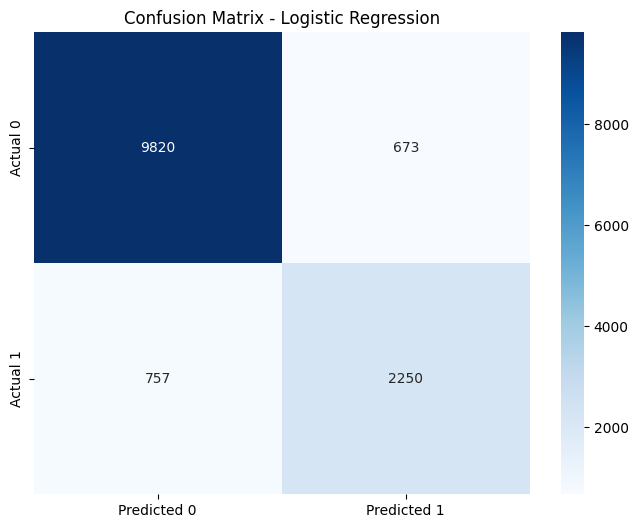


Decision Tree:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93     10493
           1       0.77      0.78      0.77      3007

    accuracy                           0.90     13500
   macro avg       0.85      0.86      0.85     13500
weighted avg       0.90      0.90      0.90     13500



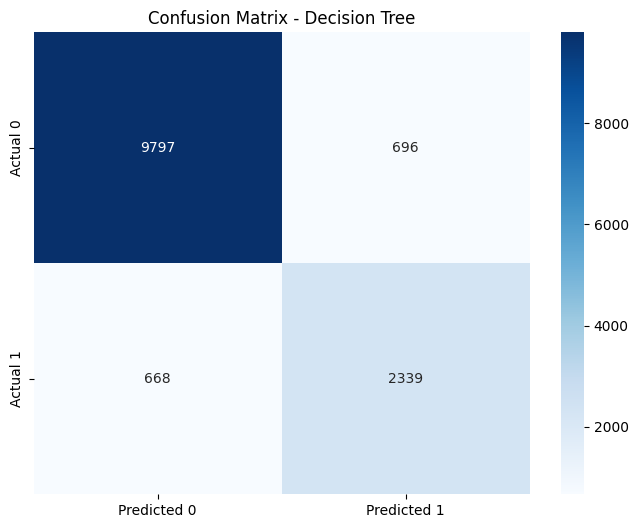


Random Forest:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95     10493
           1       0.88      0.77      0.82      3007

    accuracy                           0.93     13500
   macro avg       0.91      0.87      0.89     13500
weighted avg       0.92      0.93      0.92     13500



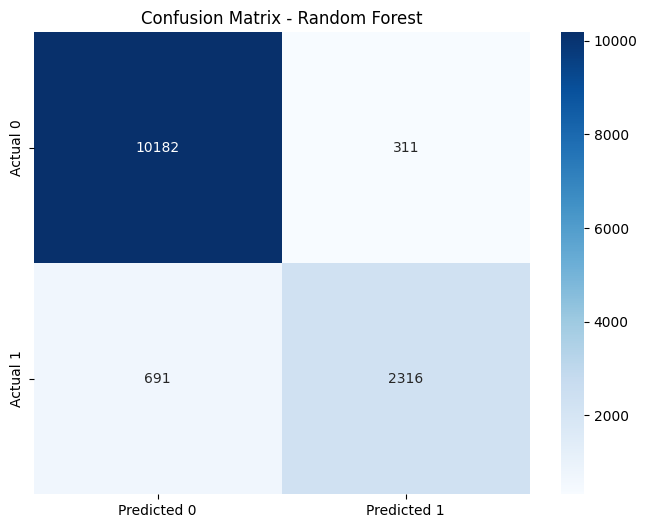


SVM:
              precision    recall  f1-score   support

           0       0.93      0.96      0.94     10493
           1       0.84      0.75      0.79      3007

    accuracy                           0.91     13500
   macro avg       0.89      0.86      0.87     13500
weighted avg       0.91      0.91      0.91     13500



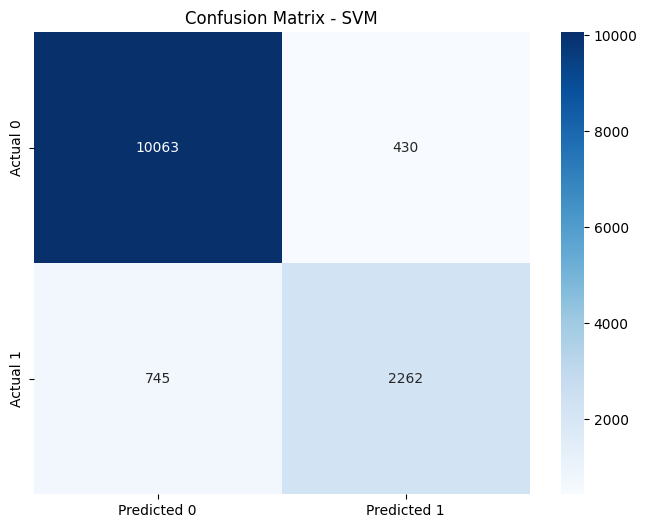

In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


X_train_processed = pd.concat([X_train.drop(categorical_features, axis=1), encoded_df_train], axis=1)
X_test_processed = pd.concat([X_test.drop(categorical_features, axis=1), encoded_df_test], axis=1)


numerical_features = X_train_processed.select_dtypes(include=['number']).columns
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_processed[numerical_features])
X_test_scaled = scaler.transform(X_test_processed[numerical_features])


X_train_final = pd.DataFrame(X_train_scaled, columns=numerical_features, index=X_train_processed.index)
X_test_final = pd.DataFrame(X_test_scaled, columns=numerical_features, index=X_test_processed.index)
X_train_final = pd.concat([X_train_final, encoded_df_train], axis=1)
X_test_final = pd.concat([X_test_final, encoded_df_test], axis=1)

models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC()
}

for name, model in models.items():
    model.fit(X_train_final, y_train)
    y_pred = model.predict(X_test_final)
    print(f"\n{name}:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title(f'Confusion Matrix - {name}')
    plt.show()


 Dimensionality Reduction with PCA:   
• Apply PCA(n_components=2) on training data.   
• Transform both training and test data.   
• Train the same models listed in section 2.  
• Evaluate using the same metrics.


Logistic Regression (with PCA):
              precision    recall  f1-score   support

           0       0.92      0.89      0.90     10493
           1       0.65      0.72      0.68      3007

    accuracy                           0.85     13500
   macro avg       0.78      0.80      0.79     13500
weighted avg       0.86      0.85      0.85     13500



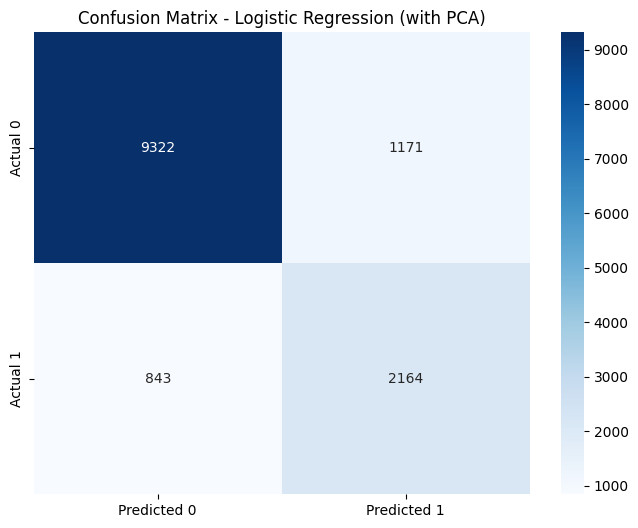


Decision Tree (with PCA):
              precision    recall  f1-score   support

           0       0.88      0.88      0.88     10493
           1       0.59      0.58      0.59      3007

    accuracy                           0.82     13500
   macro avg       0.73      0.73      0.73     13500
weighted avg       0.82      0.82      0.82     13500



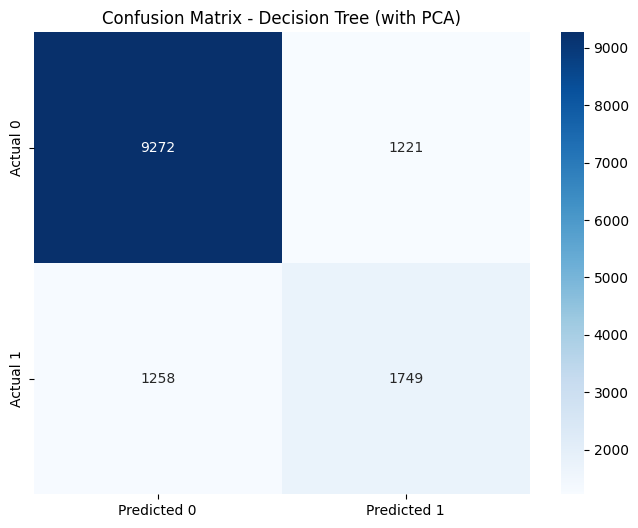


Random Forest (with PCA):
              precision    recall  f1-score   support

           0       0.89      0.92      0.91     10493
           1       0.69      0.60      0.64      3007

    accuracy                           0.85     13500
   macro avg       0.79      0.76      0.77     13500
weighted avg       0.85      0.85      0.85     13500



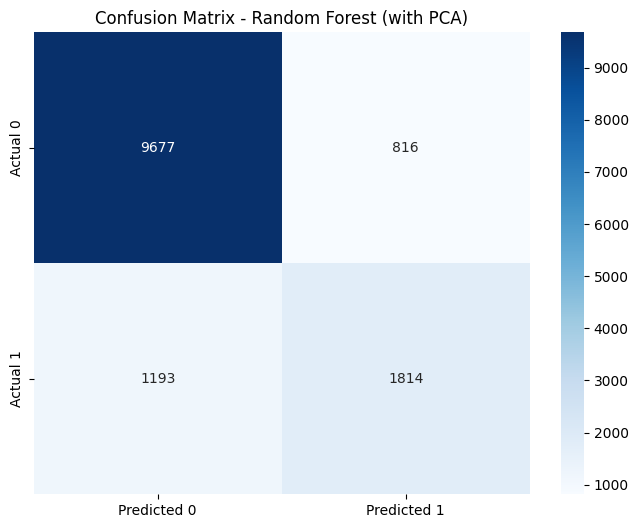


SVM (with PCA):
              precision    recall  f1-score   support

           0       0.88      0.95      0.92     10493
           1       0.78      0.56      0.65      3007

    accuracy                           0.87     13500
   macro avg       0.83      0.76      0.78     13500
weighted avg       0.86      0.87      0.86     13500



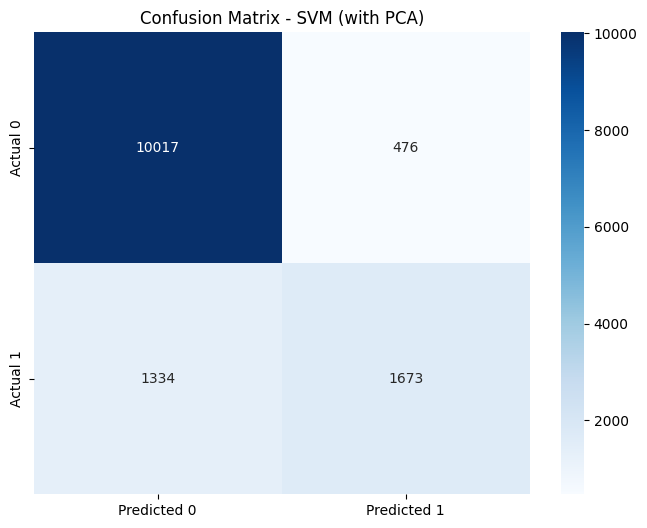

In [31]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_final)
X_test_pca = pca.transform(X_test_final)

for name, model in models.items():
    model.fit(X_train_pca, y_train)
    y_pred = model.predict(X_test_pca)
    print(f"\n{name} (with PCA):")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title(f'Confusion Matrix - {name} (with PCA)')
    plt.show()

Dimensionality Reduction with LDA:   
• Apply LinearDiscriminantAnalysis(n_components=2) on training data.   
• Transform both training and test data.   
• Train and evaluate the same models using the same metrics.

In [23]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report

lda = LinearDiscriminantAnalysis(n_components=1)
X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_test_lda = lda.transform(X_test_scaled)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC()
}

results_lda = {}
for name, model in models.items():
    model.fit(X_train_lda, y_train)
    y_pred = model.predict(X_test_lda)
    accuracy = accuracy_score(y_test, y_pred)
    results_lda[name] = {
        "accuracy": accuracy,
        "classification_report": classification_report(y_test, y_pred)
    }
    print(f"{name} (with LDA):")
    print(f"  Accuracy: {accuracy}")
    print(f"  Classification Report:\n{classification_report(y_test, y_pred)}")

Logistic Regression (with LDA):
  Accuracy: 0.8937037037037037
  Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93     10493
           1       0.78      0.73      0.75      3007

    accuracy                           0.89     13500
   macro avg       0.85      0.83      0.84     13500
weighted avg       0.89      0.89      0.89     13500

Decision Tree (with LDA):
  Accuracy: 0.8531111111111112
  Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.90      0.91     10493
           1       0.67      0.68      0.67      3007

    accuracy                           0.85     13500
   macro avg       0.79      0.79      0.79     13500
weighted avg       0.85      0.85      0.85     13500

Random Forest (with LDA):
  Accuracy: 0.8533333333333334
  Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.90      

Comparison and Analysis

<ipython-input-26-75b619ac4a1d>:42: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, pd.DataFrame([{'Model': name, 'Scenario': 'Without DR', 'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1-score': f1}])], ignore_index=True)


                  Model    Scenario  Accuracy  Precision  Recall  F1-score
0   Logistic Regression  Without DR      0.89       0.89    0.89      0.89
1         Decision Tree  Without DR      0.90       0.90    0.90      0.90
2         Random Forest  Without DR      0.93       0.92    0.93      0.92
3                   SVM  Without DR      0.91       0.91    0.91      0.91
4   Logistic Regression    With PCA      0.85       0.86    0.85      0.85
5         Decision Tree    With PCA      0.82       0.82    0.82      0.82
6         Random Forest    With PCA      0.85       0.84    0.85      0.85
7                   SVM    With PCA      0.87       0.86    0.87      0.86
8   Logistic Regression    With LDA      0.89       0.89    0.89      0.89
9         Decision Tree    With LDA      0.85       0.85    0.85      0.85
10        Random Forest    With LDA      0.85       0.85    0.85      0.85
11                  SVM    With LDA      0.89       0.89    0.89      0.89


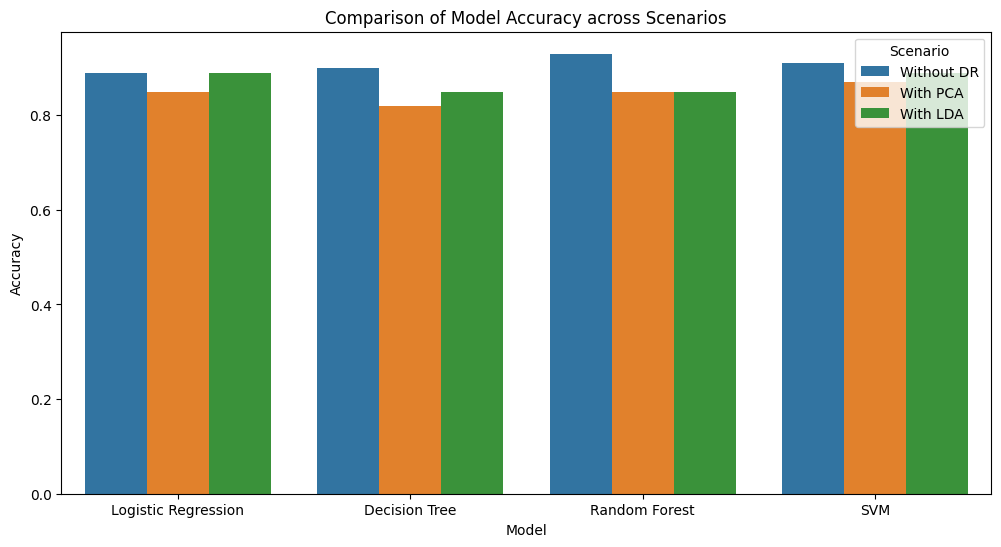

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
results_df = pd.DataFrame(columns=['Model', 'Scenario', 'Accuracy', 'Precision', 'Recall', 'F1-score'])

def extract_metrics(report):
    lines = report.split('\n')
    for line in lines:
        if "accuracy" in line.lower():
            accuracy = float(line.split()[1])
        if "weighted avg" in line.lower():
            precision = float(line.split()[2])
            recall = float(line.split()[3])
            f1 = float(line.split()[4])
    return accuracy, precision, recall, f1

models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC()
}

for name, model in models.items():
    model.fit(X_train_final, y_train)
    y_pred = model.predict(X_test_final)
    report = classification_report(y_test, y_pred)
    accuracy, precision, recall, f1 = extract_metrics(report)
    results_df = pd.concat([results_df, pd.DataFrame([{'Model': name, 'Scenario': 'Without DR', 'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1-score': f1}])], ignore_index=True)

for name, model in models.items():
    model.fit(X_train_pca, y_train)
    y_pred_pca = model.predict(X_test_pca)
    report_pca = classification_report(y_test, y_pred_pca)
    accuracy, precision, recall, f1 = extract_metrics(report_pca)
    results_df = pd.concat([results_df, pd.DataFrame([{'Model': name, 'Scenario': 'With PCA', 'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1-score': f1}])], ignore_index=True)


for name, model in models.items():
    model.fit(X_train_lda, y_train)
    y_pred_lda = model.predict(X_test_lda)
    report_lda = classification_report(y_test, y_pred_lda)
    accuracy, precision, recall, f1 = extract_metrics(report_lda)
    results_df = pd.concat([results_df, pd.DataFrame([{'Model': name, 'Scenario': 'With LDA', 'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1-score': f1}])], ignore_index=True)


print(results_df)

plt.figure(figsize=(12,6))
sns.barplot(x="Model", y="Accuracy", hue="Scenario", data=results_df)
plt.title('Comparison of Model Accuracy across Scenarios')
plt.show()